In [1]:
from pathlib import Path

In [2]:
# calibration package
ROOT = Path.cwd().parent

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Kinetics Toolkit

In [4]:
import kineticstoolkit as ktk
import kineticstoolkit_extensions.pushrimkinetics as pk

# Calibration Matrix

In [5]:
calibration_directory = ROOT / "matrix_A_offset"
calibration_matrix_file = np.load(calibration_directory / "calibration_matrix.npz")
offset_file = np.load(calibration_directory / "offset.npz")
A = calibration_matrix_file["A"]
y_scale = calibration_matrix_file["y_scale"]
offset = offset_file["offset"]

# Trial Data

In [62]:
trial = ktk.load("dynamic_calibration_trials/dynamic_calibration_measurement19")

# Referential

In [63]:
imu_directory = ROOT / "E1_E2"

In [64]:
from software.calibration.dynamic_calibration.functions import load_fixed_imu_params, apply_imu_calibration, \
    apply_calibration_forces, convert_ticks_to_radians, get_centrifuge_force

# Load IMU data
base, acc_bias, imu_info, gyro_bias = load_fixed_imu_params(imu_directory)
trial_calibrated = apply_imu_calibration(trial, base, acc_bias, gyro_bias)

trial_calibrated = apply_calibration_forces(trial_calibrated, A, offset, y_scale)
trial_calibrated = convert_ticks_to_radians(trial_calibrated)


Original angle (ticks): [45514. 45560. 45603. 45650. 45695.] ...


# Trial TimesSeries

In [65]:
ts_angles = ktk.TimeSeries(time=trial_calibrated["Encoder"]["Time"],
                           data={"Angle": trial_calibrated["Encoder"]["AngleCalibrated"]})
ts_forces = ktk.TimeSeries(time=trial_calibrated["Analog"]["Time"],
                           data={"Forces": trial_calibrated["Analog"]["ForceCalibrated"]})
ts_moments = ktk.TimeSeries(time=trial_calibrated["Analog"]["Time"],
                            data={"Moments": trial_calibrated["Analog"]["MomentsCalibrated"]})

ts_forces_moments = ts_moments.merge(ts_forces)
ts_angles_forces_moments = ts_angles.merge(ts_forces_moments, resample=True)

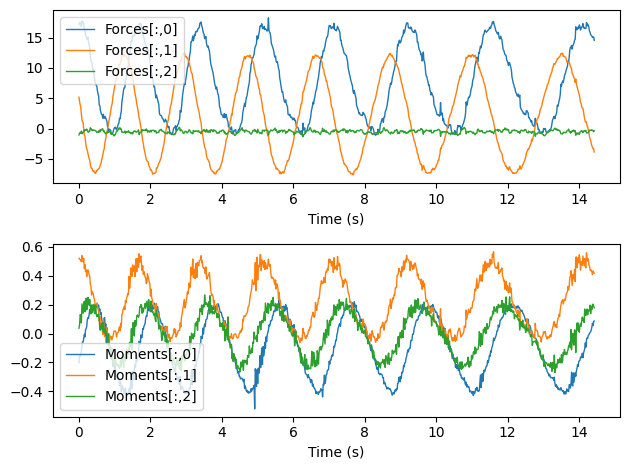

In [66]:
plt.subplot(2, 1, 1)
ts_angles_forces_moments.plot("Forces")
plt.subplot(2, 1, 2)
ts_angles_forces_moments.plot("Moments")
plt.tight_layout()

# Gyroscope Data

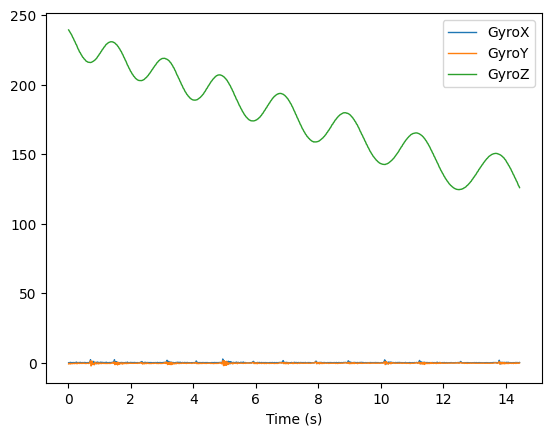

In [67]:
ts_gyro = ktk.TimeSeries(time=trial_calibrated["IMU"]["Time"],
                         data={"GyroX": trial_calibrated["IMU"]["GyroCal"][:, 0],
                               "GyroY": trial_calibrated["IMU"]["GyroCal"][:, 1],
                               "GyroZ": trial_calibrated["IMU"]["GyroCal"][:, 2]})
ts_gyro.plot()

# Remove dynamic offsets

In [68]:
trial_without_dynamic_offset = pk.remove_offsets(ts_angles_forces_moments)


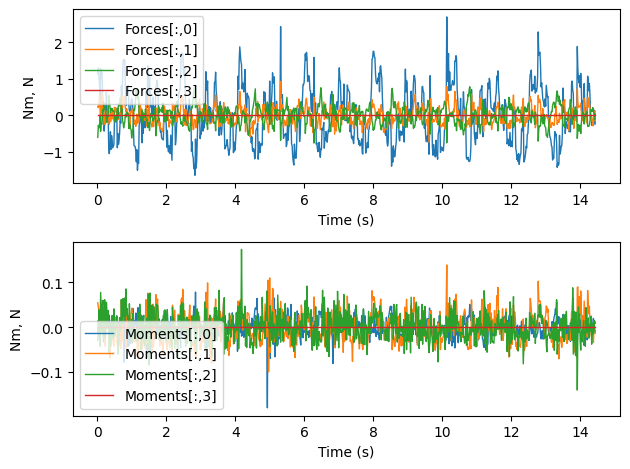

In [69]:
plt.subplot(2, 1, 1)
trial_without_dynamic_offset.plot("Forces")
plt.subplot(2, 1, 2)
trial_without_dynamic_offset.plot("Moments")
plt.tight_layout()

# Centrifugal Force

In [70]:
print("Centrifugal Force:", get_centrifuge_force(trial_without_dynamic_offset))

Original forces: [[ 1.13966936  0.24438605 -0.60427888  0.        ]
 [ 1.2989898   0.2094172  -0.27288987  0.        ]
 [ 1.08098249  0.31117163 -0.34626704  0.        ]
 [ 0.8994179   0.55303677 -0.30698362  0.        ]
 [ 0.32497007  0.13944617  0.00645959  0.        ]] ...
Centrifugal Force: [[ 1.13966936  0.24438605 -0.60427888]
 [ 1.2989898   0.2094172  -0.27288987]
 [ 1.08098249  0.31117163 -0.34626704]
 ...
 [-0.14290675 -0.15210257  0.06588052]
 [ 0.13725099  0.11261182 -0.12327185]
 [-0.23784655 -0.10078072  0.03398296]]


# Centrifugal Force vs Gyroscope

In [71]:
# Create TimeSeries for centrifugal force and gyroscope data
ts_forces_moments_gyro = trial_without_dynamic_offset.merge(ts_gyro, resample=True)
ts_forces_moments_gyro_with_offsets = ts_angles_forces_moments.merge(ts_gyro, resample=True)

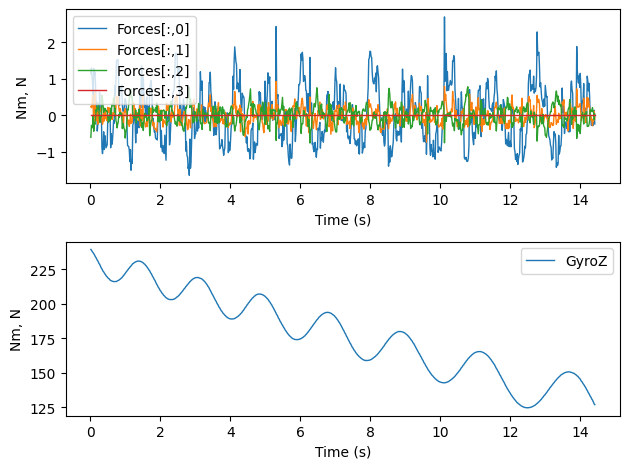

In [72]:
plt.subplot(2, 1, 1)
ts_forces_moments_gyro.plot("Forces")
plt.subplot(2, 1, 2)
ts_forces_moments_gyro.plot("GyroZ")
plt.tight_layout()

               Angle  Moments[:,0]  Moments[:,1]  Moments[:,2]  Forces[:,0]  \
0.010560    0.000000     -0.202106      0.519988      0.036659    17.157211   
0.027560    0.070563     -0.153446      0.514689      0.062876    17.493078   
0.043560    0.136524     -0.155927      0.509318      0.130291    17.402017   
0.060560    0.208621     -0.151209      0.505092      0.122387    17.316444   
0.077560    0.277651     -0.118683      0.496574      0.073179    16.791604   
...              ...           ...           ...           ...          ...   
14.359560  44.790705      0.044055      0.431032      0.165444    15.251458   
14.376560  44.829055      0.070258      0.407179      0.193506    15.033185   
14.393560  44.867404      0.055051      0.430988      0.202661    14.998807   
14.409564  44.902686      0.082573      0.421507      0.188946    15.110511   
14.426560  44.941035      0.086458      0.417035      0.178039    14.542092   

           Forces[:,1]  Forces[:,2]     GyroX     G

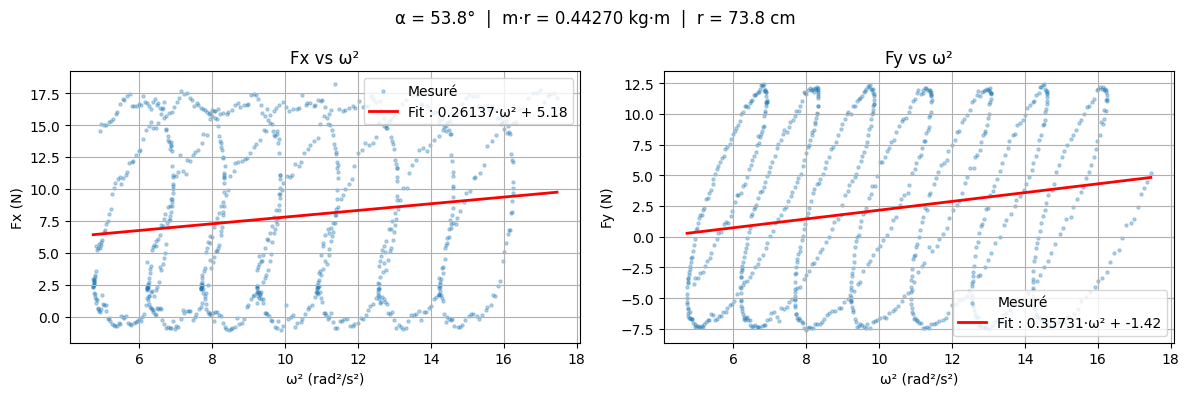

In [73]:
# 1. Données
ts_all = ts_forces_moments_gyro_with_offsets
print(ts_all.to_dataframe())

# Conversion deg/s → rad/s
omega_z    = np.deg2rad(ts_all.data["GyroZ"])
omega_z_sq = omega_z ** 2

# Vérification
print(f"ω max corrigé : {omega_z.max():.1f} rad/s  ({omega_z.max()*60/(2*np.pi):.1f} RPM)")

# Force centripète attendue
m, r = 0.6, 0.30
print(f"Force attendue à ω_max : {m * r * omega_z_sq.max():.1f} N")
# 3. Composantes de force
F_x = ts_all.data["Forces"][:, 0]
F_y = ts_all.data["Forces"][:, 1]

# 4. Filtre phases stables (dω/dt ≈ 0)
d_omega      = np.gradient(omega_z, ts_all.time)
masque_stable = np.abs(d_omega) < 50.0  # rad/s² — ajuster si besoin
valid = masque_stable & ~(np.isnan(omega_z_sq) | np.isnan(F_x) | np.isnan(F_y))
print(f"Points retenus : {valid.sum()} / {len(valid)}")

# 5. Régression indépendante sur Fx et Fy vs ω²
#    Selon l'article : Fx = m·r·cos(α)·ω²  et  Fy = m·r·sin(α)·ω²
slope_x, intercept_x = np.polyfit(omega_z_sq[valid], F_x[valid], 1)
slope_y, intercept_y = np.polyfit(omega_z_sq[valid], F_y[valid], 1)

# 6. Identifier alpha et m·r
alpha_identified = np.arctan2(slope_y, slope_x)
mr_identified    = np.sqrt(slope_x**2 + slope_y**2)

m = 0.6  # kg — masse connue
r_identified = mr_identified / m

print(f"Alpha (angle masse) : {np.rad2deg(alpha_identified):.1f}°")
print(f"m·r identifié       : {mr_identified:.5f} kg·m")
print(f"r identifié         : {r_identified*100:.1f} cm")

# 7. Modèle reconstruit
F_centri_x = mr_identified * omega_z_sq * np.cos(alpha_identified)
F_centri_y = mr_identified * omega_z_sq * np.sin(alpha_identified)

# 8. Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, F_meas, F_model, label, slope, intercept in zip(
        axes,
        [F_x[valid], F_y[valid]],
        [F_centri_x[valid], F_centri_y[valid]],
        ["Fx", "Fy"],
        [slope_x, slope_y],
        [intercept_x, intercept_y]):

    x_fit = np.linspace(omega_z_sq[valid].min(), omega_z_sq[valid].max(), 200)
    ax.scatter(omega_z_sq[valid], F_meas,  s=5, alpha=0.3, label="Mesuré")
    ax.plot(x_fit, slope * x_fit + intercept, "r-", linewidth=2,
            label=f"Fit : {slope:.5f}·ω² + {intercept:.2f}")
    ax.set_xlabel("ω² (rad²/s²)")
    ax.set_ylabel(f"{label} (N)")
    ax.set_title(f"{label} vs ω²")
    ax.legend()
    ax.grid()

plt.suptitle(f"α = {np.rad2deg(alpha_identified):.1f}°  |  m·r = {mr_identified:.5f} kg·m  |  r = {r_identified*100:.1f} cm")
plt.tight_layout()
plt.show()

Tailles : theta=866, omega_sq=866, F=866
Fx : A1·sin(θ) + A2·cos(θ) + A3 + B·ω²
  A1=2.7949, A2=8.2915, A3=7.7556, B=-0.002712
Fy : A1·sin(θ) + A2·cos(θ) + A3 + B·ω²
  A1=-9.2804, A2=2.5256, A3=2.3956, B=0.000220

Alpha : 175.4°
m·r   : 0.00272 kg·m  →  r = 0.2 cm


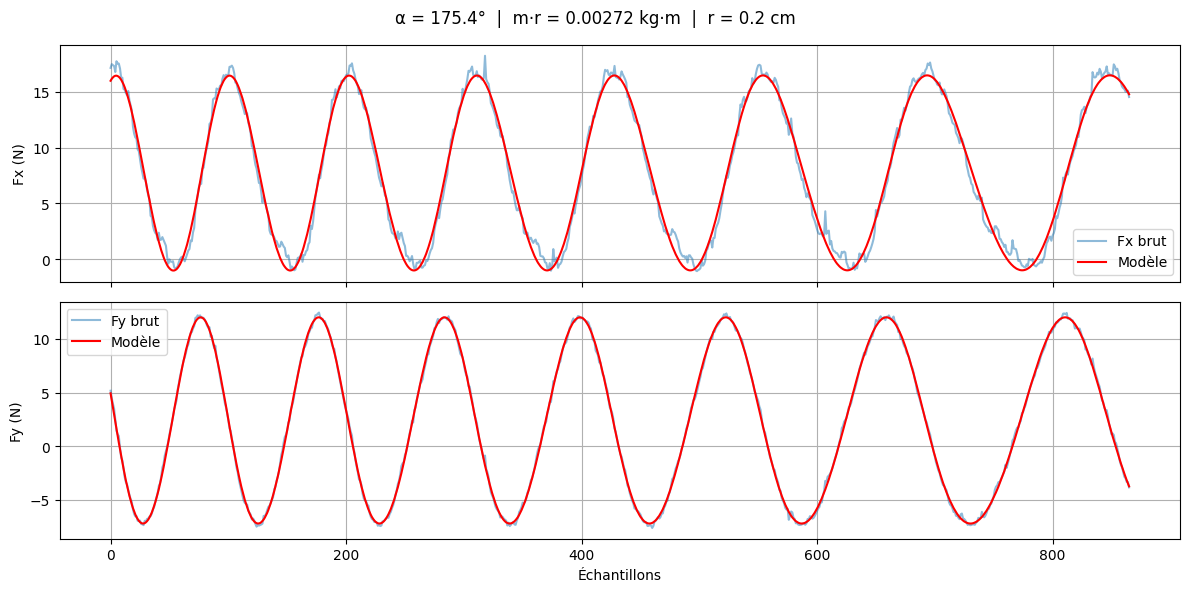

In [75]:
# 1. Créer les TimeSeries séparés avec les bonnes sources
ts_theta = ktk.TimeSeries(
    time=trial_calibrated["Encoder"]["Time"],
    data={"Angle": trial_calibrated["Encoder"]["AngleCalibrated"] % (2 * np.pi)}
)

ts_gyro_raw = ktk.TimeSeries(
    time=trial_calibrated["IMU"]["Time"],
    data={"GyroZ": np.deg2rad(trial_calibrated["IMU"]["GyroCal"][:, 2])}
)

ts_forces_raw = ktk.TimeSeries(
    time=trial_calibrated["Analog"]["Time"],
    data={"Forces": trial_calibrated["Analog"]["ForceCalibrated"]}
)

# 2. Merger tout sur la même base de temps
ts_merged = ts_theta.merge(ts_forces_raw, resample=True)
ts_merged = ts_merged.merge(ts_gyro_raw, resample=True)

# 3. Extraire les signaux alignés
theta    = ts_merged.data["Angle"]
omega    = ts_merged.data["GyroZ"]          # déjà en rad/s (converti plus haut)
omega_sq = omega ** 2
F_raw_x  = ts_merged.data["Forces"][:, 0]
F_raw_y  = ts_merged.data["Forces"][:, 1]

print(f"Tailles : theta={len(theta)}, omega_sq={len(omega_sq)}, F={len(F_raw_x)}")

# 4. Modèle étendu : sin(θ), cos(θ), 1, ω²
N = len(theta)
Q_ext = np.column_stack([
    np.sin(theta),
    np.cos(theta),
    np.ones(N),
    omega_sq
])  # N×4

# 5. Régression sur Fx et Fy
coeffs_x = np.linalg.lstsq(Q_ext, F_raw_x, rcond=None)[0]
coeffs_y = np.linalg.lstsq(Q_ext, F_raw_y, rcond=None)[0]

print("Fx : A1·sin(θ) + A2·cos(θ) + A3 + B·ω²")
print(f"  A1={coeffs_x[0]:.4f}, A2={coeffs_x[1]:.4f}, "
      f"A3={coeffs_x[2]:.4f}, B={coeffs_x[3]:.6f}")
print("Fy : A1·sin(θ) + A2·cos(θ) + A3 + B·ω²")
print(f"  A1={coeffs_y[0]:.4f}, A2={coeffs_y[1]:.4f}, "
      f"A3={coeffs_y[2]:.4f}, B={coeffs_y[3]:.6f}")

# 6. Extraire les paramètres centripètes
B_x = coeffs_x[3]  # m·r·cos(α)
B_y = coeffs_y[3]  # m·r·sin(α)

alpha_id = np.arctan2(B_y, B_x)
mr_id    = np.sqrt(B_x**2 + B_y**2)
m = 1.1  # kg
# m = 0.63  # kg
print(f"\nAlpha : {np.rad2deg(alpha_id):.1f}°")
print(f"m·r   : {mr_id:.5f} kg·m  →  r = {mr_id/m*100:.1f} cm")

# 7. Visualisation du fit
F_x_fit = Q_ext @ coeffs_x
F_y_fit = Q_ext @ coeffs_y

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(F_raw_x, alpha=0.5, label="Fx brut")
axes[0].plot(F_x_fit, "r-", linewidth=1.5, label="Modèle")
axes[0].set_ylabel("Fx (N)")
axes[0].legend(); axes[0].grid()

axes[1].plot(F_raw_y, alpha=0.5, label="Fy brut")
axes[1].plot(F_y_fit, "r-", linewidth=1.5, label="Modèle")
axes[1].set_ylabel("Fy (N)")
axes[1].legend(); axes[1].grid()

plt.xlabel("Échantillons")
plt.suptitle(f"α = {np.rad2deg(alpha_id):.1f}°  |  m·r = {mr_id:.5f} kg·m  |  r = {mr_id/m*100:.1f} cm")
plt.tight_layout()
plt.show()

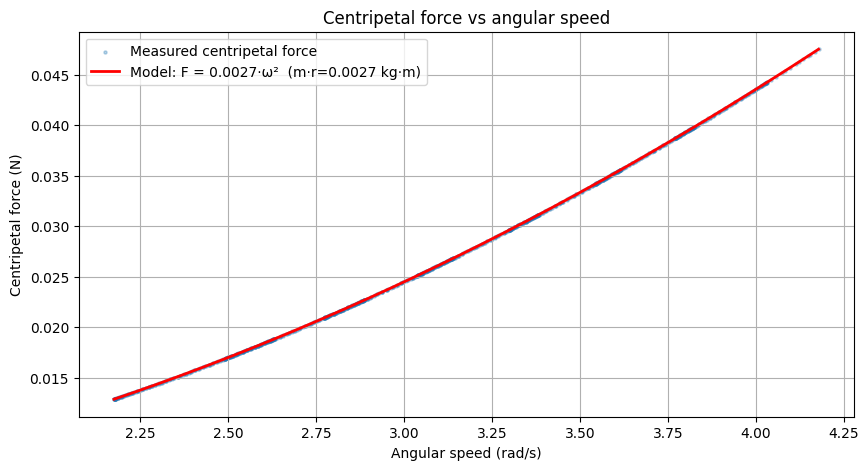

<Figure size 640x480 with 0 Axes>

In [77]:
# Theoretical centripetal force (model)
F_centri_model = mr_id * omega_sq  # = m·r·ω²

# Measured centripetal force (component extracted from raw signal)
F_centri_x_meas = B_x * omega_sq  # centripetal contribution on Fx
F_centri_y_meas = B_y * omega_sq  # centripetal contribution on Fy
F_centri_meas   = np.sqrt(F_centri_x_meas**2 + F_centri_y_meas**2)

# Angular speed in rad/s
omega_rad = np.abs(omega)  # already in rad/s

# Sort by increasing speed for a clean plot
sort_idx = np.argsort(omega_rad)

plt.figure(figsize=(10, 5))
plt.scatter(omega_rad, F_centri_meas, s=5, alpha=0.3, label="Measured centripetal force")
plt.plot(omega_rad[sort_idx],
         F_centri_model[sort_idx],
         "r-", linewidth=2,
         label=f"Model: F = {mr_id:.4f}·ω²  (m·r={mr_id:.4f} kg·m)")
plt.xlabel("Angular speed (rad/s)")
plt.ylabel("Centripetal force (N)")
plt.title(f"Centripetal force vs angular speed")
plt.legend()
plt.grid()
plt.show()

plt.savefig("centripetal_force_vs_omega.png", dpi=300, bbox_inches="tight")

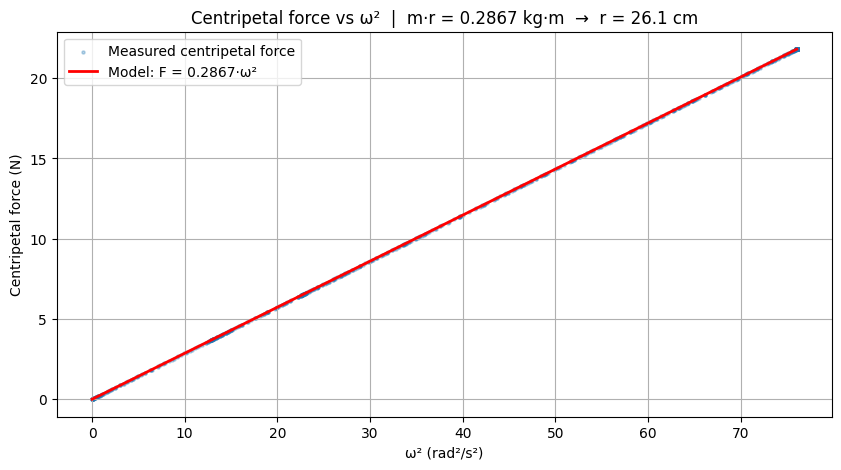

In [61]:
plt.figure(figsize=(10, 5))
plt.scatter(omega_sq, F_centri_meas, s=5, alpha=0.3, label="Measured centripetal force")
plt.plot(np.sort(omega_sq),
         mr_id * np.sort(omega_sq),
         "r-", linewidth=2,
         label=f"Model: F = {mr_id:.4f}·ω²")
plt.xlabel("ω² (rad²/s²)")
plt.ylabel("Centripetal force (N)")
plt.title(f"Centripetal force vs ω²  |  m·r = {mr_id:.4f} kg·m  →  r = {mr_id/m*100:.1f} cm")
plt.legend()
plt.grid()
plt.show()